In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [45]:
df_titanic = sns.load_dataset('titanic')

In [46]:
print(df_titanic.info())
print(df_titanic.isna().sum())
#As passoas com a passagem (pclass) mais cara, sobreviveram mais do que as com ingressos mais baratas?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
survived         0
pclass           0
sex              0
age            17

In [47]:
media_aparada = stats.trim_mean(df_titanic['age'].dropna(), 0.1)
df_titanic['age'] = df_titanic['age'].fillna(media_aparada)

In [48]:
nome = [(df_titanic['embark_town'] == 'Cherbourg'), (df_titanic['embark_town'] == 'Southampton'), (df_titanic['embark_town'] == 'Queenstown')]
sigla_cidadeEmbacarda =['C', 'S', 'Q']

df_titanic['embarked'] = np.select(nome, sigla_cidadeEmbacarda, default='Não Informado')
df_titanic['embark_town'] = df_titanic['embark_town'].fillna('Não Informado')

In [49]:
df_titanic['deck'] = df_titanic['deck'].astype(str).fillna('Não Informado')

In [50]:
#Tradução dos nomes das colunas

df_titanic = df_titanic.rename(columns={'age': 'idade'})
df_titanic = df_titanic.rename(columns={'survived': 'sobreviveu'})
df_titanic = df_titanic.rename(columns={'pclass': 'pclasse'})
df_titanic = df_titanic.rename(columns={'sibsp': 'n_irmaosEsposa'})
df_titanic = df_titanic.rename(columns={'sex': 'sexo'})
df_titanic = df_titanic.rename(columns={'parch': 'n_paisFilhos'})
df_titanic = df_titanic.rename(columns={'fare': 'preco_passagem'})
df_titanic = df_titanic.rename(columns={'embarked': 'local_embarque'})
df_titanic = df_titanic.rename(columns={'who': 'quem'})
df_titanic = df_titanic.rename(columns={'adult_male': 'homem_adulto'})
df_titanic = df_titanic.rename(columns={'deck': 'cabine'})
df_titanic = df_titanic.rename(columns={'embark_town': 'cidade_embarque'})
df_titanic = df_titanic.rename(columns={'alive': 'vivo'})
df_titanic = df_titanic.rename(columns={'alone': 'sozinho'})
df_titanic = df_titanic.rename(columns={'class': 'classe'})

In [ ]:
#Tradução dos dados

def traducao(coluna:str,original:list, traduzido:list):
  condicoes = [df_titanic[coluna] == item for item in original]
  df_titanic[coluna] = np.select(condicoes, traduzido, default=df_titanic[coluna])
  return df_titanic[coluna]

traducao('sexo', ['male', 'female'], ['Macho', 'Femea'])
traducao('quem', ['man', 'woman'], ['Homem', 'Mulher'])
traducao('classe', ['First', 'Second', 'Third'], ['Primeira', 'Segunda', 'Terceira'])
traducao('vivo', ['yes', 'no'], ['Sim', 'Nao'])

In [53]:
print(df_titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sobreviveu       891 non-null    int64  
 1   pclasse          891 non-null    int64  
 2   sexo             891 non-null    object 
 3   idade            891 non-null    float64
 4   n_irmaosEsposa   891 non-null    int64  
 5   n_paisFilhos     891 non-null    int64  
 6   preco_passagem   891 non-null    float64
 7   local_embarque   891 non-null    object 
 8   classe           891 non-null    object 
 9   quem             891 non-null    object 
 10  homem_adulto     891 non-null    bool   
 11  cabine           891 non-null    object 
 12  cidade_embarque  891 non-null    object 
 13  vivo             891 non-null    object 
 14  sozinho          891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB
None


In [52]:
print(df_titanic.describe())

       sobreviveu     pclasse       idade  n_irmaosEsposa  n_paisFilhos  \
count  891.000000  891.000000  891.000000      891.000000    891.000000   
mean     0.383838    2.308642   29.613719        0.523008      0.381594   
std      0.486592    0.836071   13.003148        1.102743      0.806057   
min      0.000000    1.000000    0.420000        0.000000      0.000000   
25%      0.000000    2.000000   22.000000        0.000000      0.000000   
50%      0.000000    3.000000   29.269231        0.000000      0.000000   
75%      1.000000    3.000000   35.000000        1.000000      0.000000   
max      1.000000    3.000000   80.000000        8.000000      6.000000   

       preco_passagem  
count      891.000000  
mean        32.204208  
std         49.693429  
min          0.000000  
25%          7.910400  
50%         14.454200  
75%         31.000000  
max        512.329200  


In [57]:
print(df_titanic.head())

   sobreviveu  pclasse   sexo  idade  n_irmaosEsposa  n_paisFilhos  \
0           0        3  Macho   22.0               1             0   
1           1        1  Femea   38.0               1             0   
2           1        3  Femea   26.0               0             0   
3           1        1  Femea   35.0               1             0   
4           0        3  Macho   35.0               0             0   

   preco_passagem local_embarque    classe    quem  homem_adulto cabine  \
0          7.2500              S  Terceira   Homem          True    nan   
1         71.2833              C  Primeira  Mulher         False      C   
2          7.9250              S  Terceira  Mulher         False    nan   
3         53.1000              S  Primeira  Mulher         False      C   
4          8.0500              S  Terceira   Homem          True    nan   

  cidade_embarque vivo  sozinho  
0     Southampton  Nao    False  
1       Cherbourg  Sim    False  
2     Southampton  Sim    

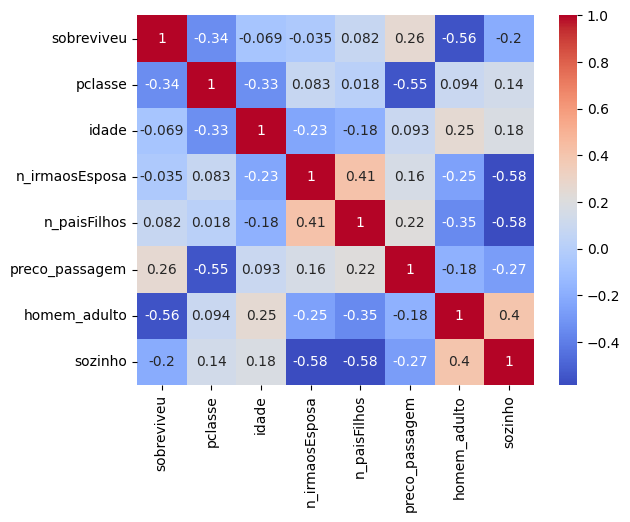

In [54]:
corr = df_titanic.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

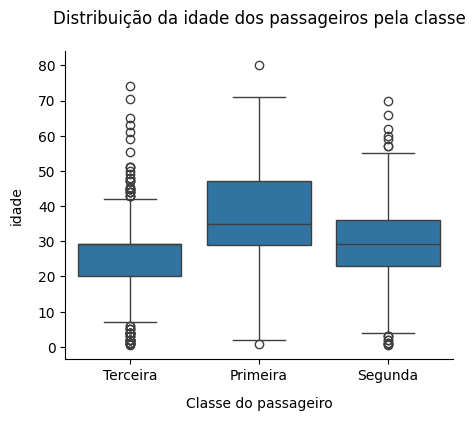

In [55]:
plt.figure(figsize=(5, 4))
sns.boxplot(x='classe',
            y='idade',
            data=df_titanic)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Distribuição da idade dos passageiros pela classe', pad=20)
plt.xlabel('Classe do passageiro', labelpad=10)
plt.ylabel('idade', labelpad=10)

plt.show()

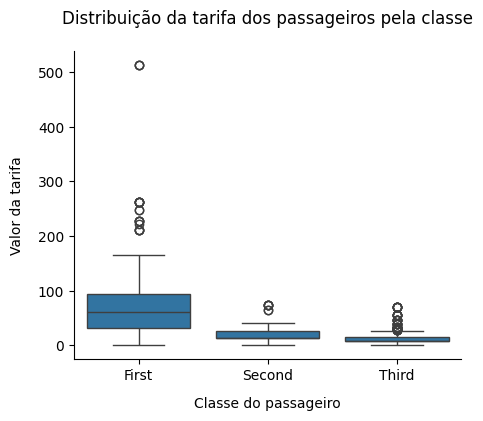

In [19]:
plt.figure(figsize=(5, 4))
sns.boxplot(x='classe',
            y='preco_passagem',
            data=df_titanic)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Distribuição da tarifa dos passageiros pela classe', pad=20)
plt.xlabel('Classe do passageiro', labelpad=10)
plt.ylabel('Valor da tarifa', labelpad=10)

plt.show()

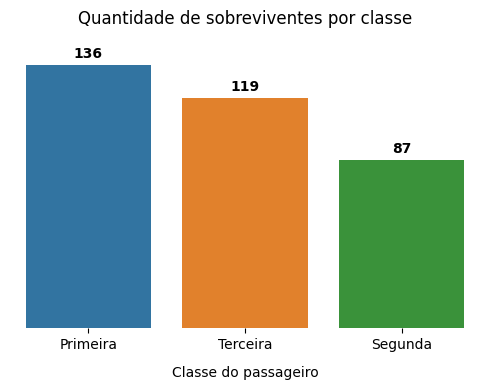

classe
Primeira    0.629630
Segunda     0.472826
Terceira    0.242363
Name: sobreviveu, dtype: float64


In [61]:
plt.figure(figsize=(5, 4))
sns.countplot(x='classe', data=df_titanic[df_titanic['sobreviveu'] == 1], hue='classe')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.xlabel('Classe do passageiro', labelpad=10)
plt.ylabel('')
plt.yticks([])
plt.title("Quantidade de sobreviventes por classe", pad=20)

for spine in plt.gca().spines.values():
  spine.set_visible(False)

for container in plt.gca().containers:
  plt.gca().bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(df_titanic.groupby('classe')['sobreviveu'].mean())

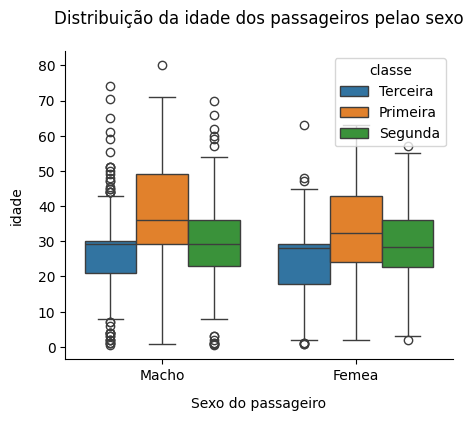

In [58]:
plt.figure(figsize=(5, 4))
sns.boxplot(x='sexo',
            y='idade',
            data=df_titanic, hue='classe')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Distribuição da idade dos passageiros pelao sexo', pad=20)
plt.xlabel('Sexo do passageiro', labelpad=10)
plt.ylabel('idade', labelpad=10)

plt.show()

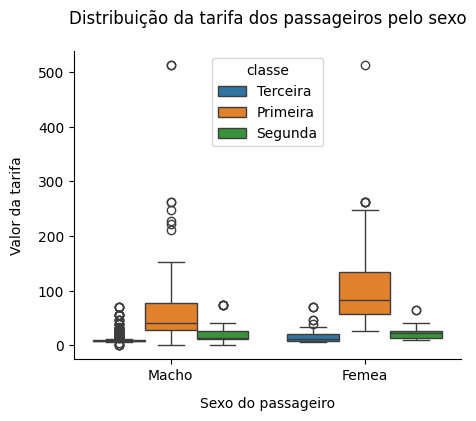

In [59]:
plt.figure(figsize=(5, 4))
sns.boxplot(x='sexo',
            y='preco_passagem',
            data=df_titanic, hue='classe')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Distribuição da tarifa dos passageiros pelo sexo', pad=20)
plt.xlabel('Sexo do passageiro', labelpad=10)
plt.ylabel('Valor da tarifa', labelpad=10)

plt.show()

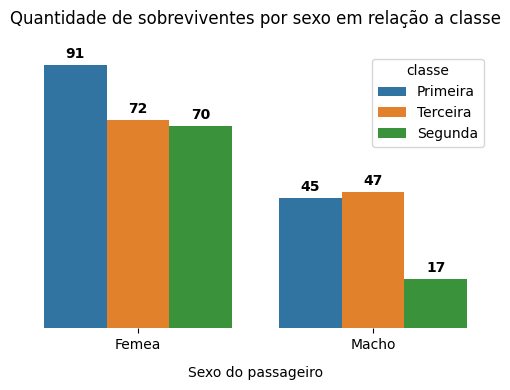

sexo
Femea    0.742038
Macho    0.188908
Name: sobreviveu, dtype: float64


In [60]:
plt.figure(figsize=(5, 4))
sns.countplot(x='sexo', data=df_titanic[df_titanic['sobreviveu'] == 1], hue='classe')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.xlabel('Sexo do passageiro', labelpad=10)
plt.ylabel('')
plt.yticks([])
plt.title('Quantidade de sobreviventes por sexo em relação a classe', pad=20)
for spine in plt.gca().spines.values():
  spine.set_visible(False)

for container in plt.gca().containers:
  plt.gca().bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(df_titanic.groupby('sexo')['sobreviveu'].mean())